In [3]:
%pip install matplotlib seaborn pandas scikit-learn simpletransformers torch

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
%pip install contractions textstat wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string
import contractions
import textstat

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

from datasets import Dataset
import torch

sns.set_style("whitegrid")

In [6]:
column_names = [
    'id',
    'label',
    'statement',
    'subjects',
    'speaker',
    'speaker_job',
    'state_info',
    'party_affiliation',
    'barely_true_counts',
    'false_counts',
    'half_true_counts',
    'mostly_true_counts',
    'pants_on_fire_counts',
    'context'
]

train_df = pd.read_table('Dataset/train.tsv')
test_df = pd.read_table('Dataset/test.tsv')
valid_df = pd.read_table('Dataset/valid.tsv')

train_df.columns = column_names
valid_df.columns = column_names
test_df.columns = column_names

print(train_df.shape)
print(valid_df.shape)
print(test_df.shape)

(10239, 14)
(1283, 14)
(1266, 14)


In [7]:
train_df.head()

,id,label,statement,subjects,speaker,speaker_job,state_info,party_affiliation,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_on_fire_counts,context
0,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
1,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
2,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release
3,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN
4,12465.json,true,The Chicago Bears have had more starting quart...,education,robin-vos,Wisconsin Assembly speaker,Wisconsin,republican,0.0,3.0,2.0,5.0,1.0,a an online opinion-piece


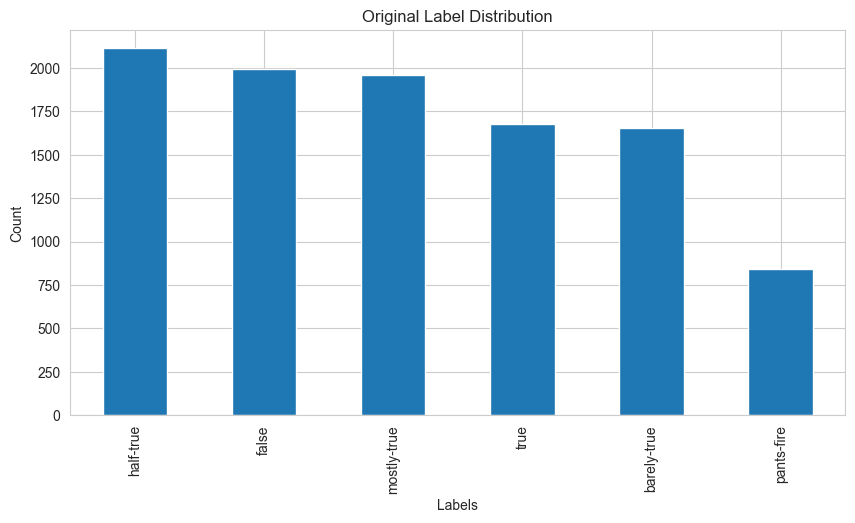

In [8]:
plt.figure(figsize=(10,5))
train_df['label'].value_counts().plot(kind='bar')
plt.title('Original Label Distribution')
plt.xlabel('Labels')
plt.ylabel('Count')
plt.show()

Convert Multi-Class to Binary Labels

In [9]:
fake_labels = ['pants-fire', 'false', 'barely-true']
real_labels = ['half-true', 'mostly-true', 'true']


def convert_label(label):
    if label in fake_labels:
        return 0
    else:
        return 1


train_df['target'] = train_df['label'].apply(convert_label)
valid_df['target'] = valid_df['label'].apply(convert_label)
test_df['target'] = test_df['label'].apply(convert_label)

train_df[['label', 'target']].head()

,label,target
0,half-true,1
1,mostly-true,1
2,false,0
3,half-true,1
4,true,1


Text Cleaning Function

In [10]:
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))


def clean_text(text):
    text = str(text).lower()

    text = contractions.fix(text)

    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'www\S+', '', text)

    text = re.sub(r'\d+', '', text)

    text = text.translate(str.maketrans('', '', string.punctuation))

    text = re.sub(r'\s+', ' ', text).strip()

    words = text.split()
    words = [word for word in words if word not in stop_words]

    return ' '.join(words)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\AMRUTHA\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Apply Cleaning

In [11]:
train_df['clean_text'] = train_df['statement'].apply(clean_text)
valid_df['clean_text'] = valid_df['statement'].apply(clean_text)
test_df['clean_text'] = test_df['statement'].apply(clean_text)

train_df[['statement', 'clean_text']].head()

,statement,clean_text
0,When did the decline of coal start? It started...,decline coal start started natural gas took st...
1,"Hillary Clinton agrees with John McCain ""by vo...",hillary clinton agrees john mccain voting give...
2,Health care reform legislation is likely to ma...,health care reform legislation likely mandate ...
3,The economic turnaround started at the end of ...,economic turnaround started end term
4,The Chicago Bears have had more starting quart...,chicago bears starting quarterbacks last years...


Linguistic Feature Engineering

In [12]:

def extract_features(text):

    text = str(text)

    num_chars = len(text)
    num_words = len(text.split())
    num_sentences = len(re.split(r'[.!?]+', text))

    avg_word_length = np.mean([len(word) for word in text.split()]) if num_words > 0 else 0

    exclamation_count = text.count('!')
    question_count = text.count('?')
    capital_ratio = sum(1 for c in text if c.isupper()) / (len(text)+1)

    readability = textstat.flesch_reading_ease(text)

    return pd.Series([
        num_chars,
        num_words,
        num_sentences,
        avg_word_length,
        exclamation_count,
        question_count,
        capital_ratio,
        readability
    ])

Create Feature Columns

In [13]:
feature_names = [
    'num_chars',
    'num_words',
    'num_sentences',
    'avg_word_length',
    'exclamation_count',
    'question_count',
    'capital_ratio',
    'readability'
]

train_df[feature_names] = train_df['statement'].apply(extract_features)
valid_df[feature_names] = valid_df['statement'].apply(extract_features)
test_df[feature_names] = test_df['statement'].apply(extract_features)

train_df.head()

,id,label,statement,subjects,speaker,speaker_job,state_info,party_affiliation,barely_true_counts,false_counts,...,target,clean_text,num_chars,num_words,num_sentences,avg_word_length,exclamation_count,question_count,capital_ratio,readability
0,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,...,1,decline coal start started natural gas took st...,141.0,24.0,4.0,4.916667,0.0,1.0,0.042254,60.705000
1,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,...,1,hillary clinton agrees john mccain voting give...,105.0,19.0,2.0,4.578947,0.0,0.0,0.075472,62.876316
2,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,...,0,health care reform legislation likely mandate ...,78.0,12.0,2.0,5.583333,0.0,0.0,0.012658,53.655000
3,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,...,1,economic turnaround started end term,54.0,10.0,2.0,4.500000,0.0,0.0,0.018182,61.325000
4,12465.json,true,The Chicago Bears have had more starting quart...,education,robin-vos,Wisconsin Assembly speaker,Wisconsin,republican,0.0,3.0,...,1,chicago bears starting quarterbacks last years...,155.0,27.0,2.0,4.777778,0.0,0.0,0.032051,54.096667


Compare Linguistic Features

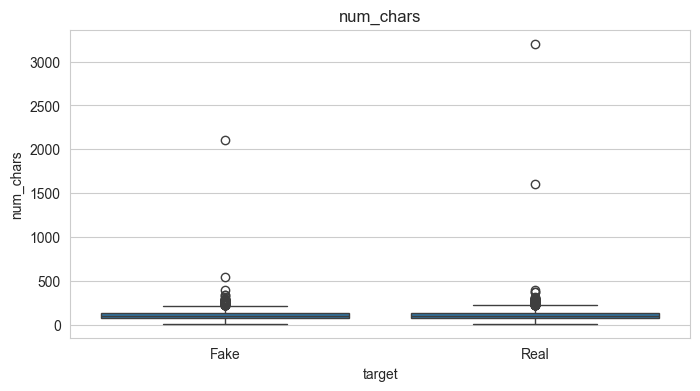

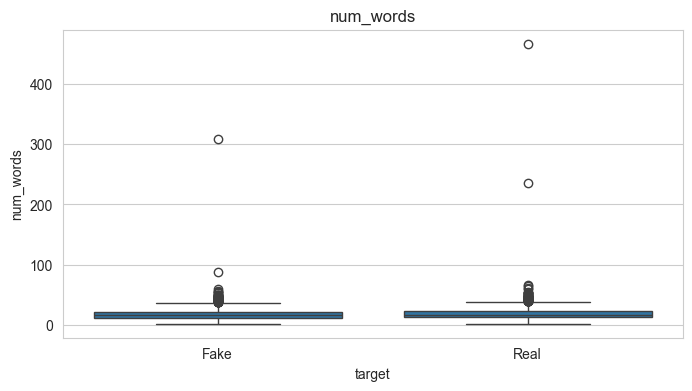

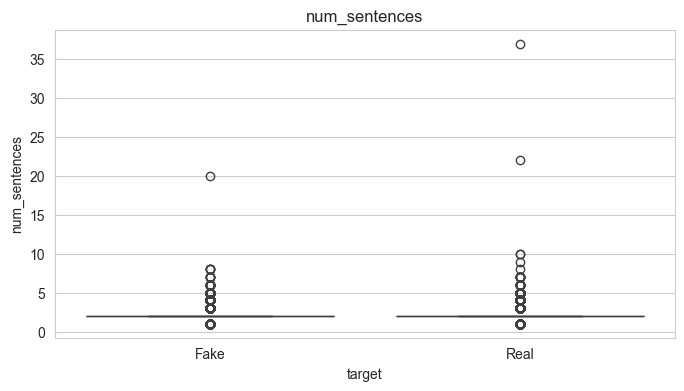

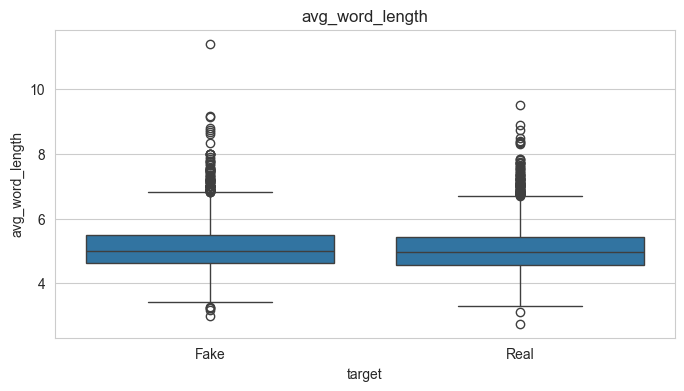

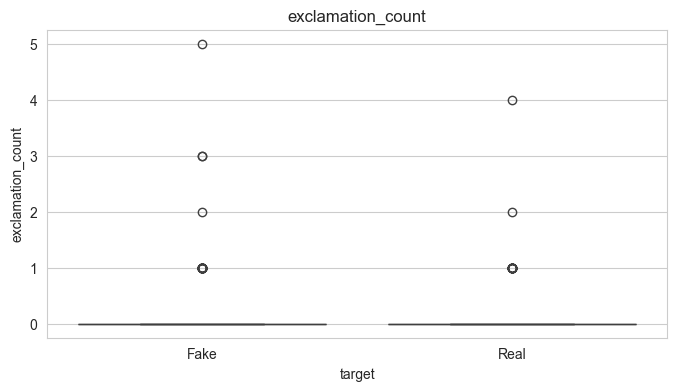

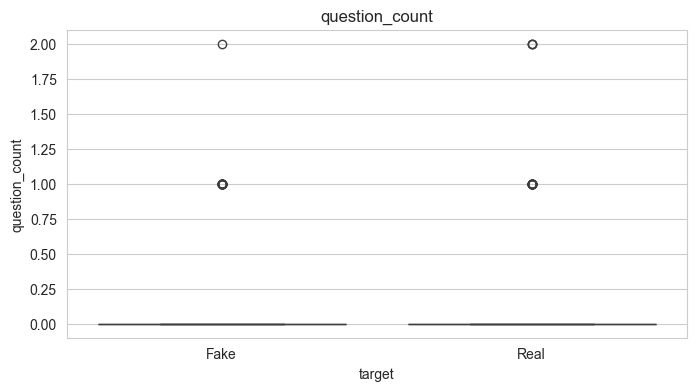

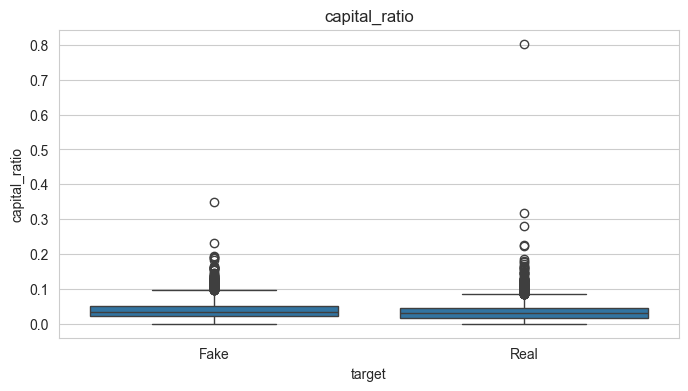

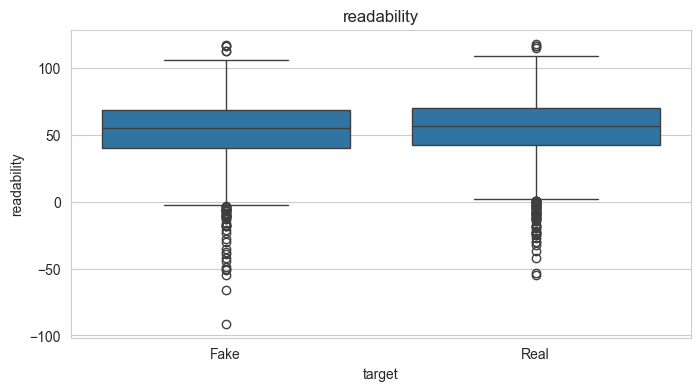

In [14]:
for feature in feature_names:

    plt.figure(figsize=(8,4))

    sns.boxplot(x='target', y=feature, data=train_df)

    plt.xticks([0,1], ['Fake', 'Real'])
    plt.title(feature)

    plt.show()

Word Cloud for Fake News

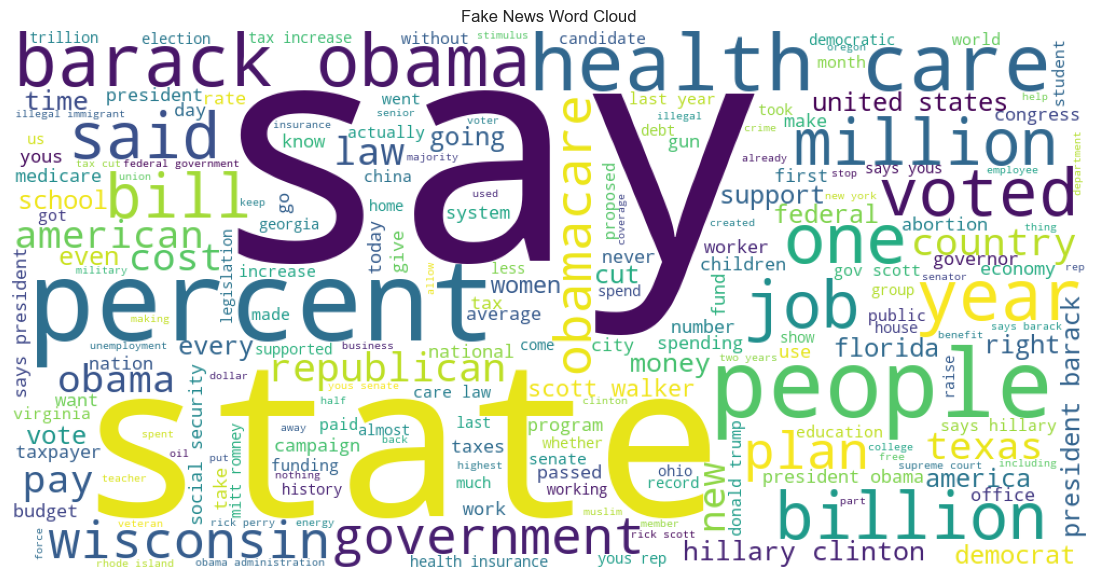

In [15]:
fake_text = ' '.join(train_df[train_df['target']==0]['clean_text'])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(fake_text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Fake News Word Cloud')
plt.show()

Word Cloud for Real News

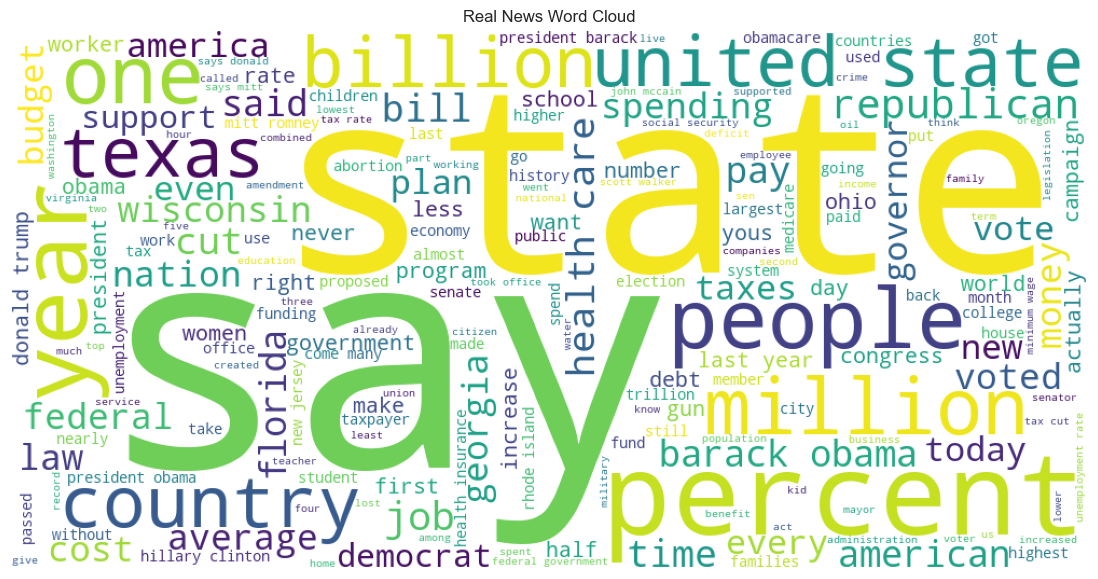

In [16]:
real_text = ' '.join(train_df[train_df['target']==1]['clean_text'])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(real_text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Real News Word Cloud')
plt.show()

TF-IDF Vectorization

In [17]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

X_train_tfidf = vectorizer.fit_transform(train_df['clean_text'])
X_valid_tfidf = vectorizer.transform(valid_df['clean_text'])
X_test_tfidf = vectorizer.transform(test_df['clean_text'])

y_train = train_df['target']
y_valid = valid_df['target']
y_test = test_df['target']

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Logistic Regression
# We use the X_train_tfidf and y_train variables your teammate defined
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_model.fit(X_train_tfidf, y_train)
lr_preds = lr_model.predict(X_test_tfidf)

print("--- Logistic Regression Results ---")
print(classification_report(y_test, lr_preds))

# 2. Gradient Boosting
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1)
gb_model.fit(X_train_tfidf, y_train)
gb_preds = gb_model.predict(X_test_tfidf)

print("--- Gradient Boosting Results ---")
print(classification_report(y_test, gb_preds))

--- Logistic Regression Results ---
              precision    recall  f1-score   support

           0       0.54      0.57      0.55       553
           1       0.65      0.63      0.64       713

    accuracy                           0.60      1266
   macro avg       0.60      0.60      0.60      1266
weighted avg       0.61      0.60      0.60      1266

--- Gradient Boosting Results ---
              precision    recall  f1-score   support

           0       0.59      0.21      0.31       553
           1       0.59      0.89      0.71       713

    accuracy                           0.59      1266
   macro avg       0.59      0.55      0.51      1266
weighted avg       0.59      0.59      0.53      1266



In [19]:
pip install --upgrade transformers simpletransformers

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
!python -m pip install "accelerate>=1.1.0" torch


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
from transformers import pipeline
import pandas as pd

# 1. Load the model
pipe = pipeline("text-classification", model="distilbert-base-uncased-finetuned-sst-2-english")

# 2. Run it on the first 50 rows of your test data (fast and enough for a demo)
samples = test_df.head(50)
texts = samples['clean_text'].tolist()
predictions = pipe(texts)

# 3. Add results to a small table
results_df = pd.DataFrame({
    'Statement': [t[:100] + "..." for t in texts],
    'Prediction': [p['label'] for p in predictions],
    'Confidence': [round(p['score'], 4) for p in predictions]
})

print("--- TRANSFORMER PREDICTIONS SUMMARY ---")
print(results_df.head())
print("\nPrediction Counts:")
print(results_df['Prediction'].value_counts())

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 1062.19it/s]


--- TRANSFORMER PREDICTIONS SUMMARY ---
                                           Statement Prediction  Confidence
0       wisconsin pace double number layoffs year...   NEGATIVE      0.9989
1         says john mccain done nothing help vets...   NEGATIVE      0.9968
2  suzanne bonamici supports plan cut choice medi...   POSITIVE      0.9077
3  asked reporter whether hes center criminal sch...   NEGATIVE      0.9815
4  past five years federal government paid millio...   NEGATIVE      0.9325

Prediction Counts:
Prediction
NEGATIVE    39
POSITIVE    11
Name: count, dtype: int64


In [23]:
import torch
from torch.utils.data import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

# 1. Custom Dataset class to handle your teammate's dataframe format
class NewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        # We use .tolist() to ensure the data is in the correct format for the tokenizer
        self.encodings = tokenizer(texts.tolist(), truncation=True, padding=True, max_length=max_len)
        self.labels = labels.tolist()

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# 2. Initialize DistilBERT (The professional standard for this task)
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# 3. Prepare the datasets
# Train on 500 rows and test on 100 rows
train_dataset = NewsDataset(train_df['clean_text'].head(500), train_df['target'].head(500), tokenizer)
test_dataset  = NewsDataset(test_df['clean_text'].head(100),  test_df['target'].head(100),  tokenizer)

# 4. Define minimal training arguments for a fast run
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=1,              # 1 epoch is enough for the project demo
    per_device_train_batch_size=16,
    logging_dir='./logs',
    save_strategy="no",              # Prevents filling up your disk with checkpoints
    report_to="none"                 # Keeps the output clean
)

# 5. Initialize the Trainer and start fine-tuning
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset
)

print("Starting DistilBERT Training...")
trainer.train()

# 6. Evaluation (to see your final performance)
metrics = trainer.evaluate(test_dataset)
print("Final Results:", metrics)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 2591.25it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Starting DistilBERT Training...


c:\Users\AMRUTHA\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss


Training Loss,Validation Loss,Step
No log,0.689846,32


Final Results: {'eval_loss': 0.6898460388183594}
